In [1]:
import nibabel as nib
import numpy as np
import glob
import os
from scipy.stats import ttest_1samp
from scipy import stats
import matplotlib.pyplot as plt
from nilearn.plotting import plot_stat_map, plot_glass_brain
from nilearn.image import resample_to_img

## glm1

In [2]:
# Set the parent directory where the contrast images are stored
parent_dir = '/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/bids_fmri_data/'  # Replace with your parent directory

# Recursively find all contrast images named 'ess_0001.nii'
contrast_files = sorted(glob.glob(os.path.join(parent_dir, '**', 'glm1/ess_0001.nii'), recursive=True))

# Check if we have any files
if not contrast_files:
    raise FileNotFoundError("No contrast images found in the specified directory.")

In [3]:
# Load the contrast images and stack them into a 4D array
contrast_imgs = [nib.load(img_file) for img_file in contrast_files]
contrast_data = np.stack([img.get_fdata() for img in contrast_imgs], axis=-1)

In [4]:
type(contrast_data)

numpy.ndarray

In [5]:
contrast_data.shape

(79, 95, 79, 16)

In [6]:
contrast_data.size

9486320

In [7]:
np.isnan(contrast_data).sum()

5943288

In [8]:
# setting nan values to zero
contrast_data = np.nan_to_num(contrast_data, nan=0.0)

In [9]:
np.isnan(contrast_data).sum()

0

In [10]:
constant_slices = np.all(contrast_data == contrast_data[..., :1], axis=-1)
print(f"Number of constant slices: {np.sum(constant_slices)}")

Number of constant slices: 323684


In [11]:
inf_values = np.isinf(contrast_data).any()
print(f"Are there any infinity values? {'Yes' if inf_values else 'No'}")

Are there any infinity values? No


In [12]:
# Perform group-level analysis (one-sample t-test against zero)
t_vals, p_vals = ttest_1samp(contrast_data, 0, axis=-1)

# Create NIfTI images for the t-values and p-values
affine = contrast_imgs[0].affine
t_img = nib.Nifti1Image(t_vals, affine)
p_img = nib.Nifti1Image(p_vals, affine)

# Save the resulting images
output_dir = './'  # Replace with your output directory
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

t_img_file = os.path.join(output_dir, 'glm1/group_t_values.nii')
p_img_file = os.path.join(output_dir, 'glm1/group_p_values.nii')

nib.save(t_img, t_img_file)
nib.save(p_img, p_img_file)

print(f"Group-level t-values saved to {t_img_file}")
print(f"Group-level p-values saved to {p_img_file}")

Group-level t-values saved to ./glm1/group_t_values.nii
Group-level p-values saved to ./glm1/group_p_values.nii


In [13]:
np.sum(p_vals < 0.05)

179323

In [14]:
np.sum(p_vals > 0.05)

89888

In [15]:
p_vals.size

592895

In [16]:
np.sum(p_vals < 0.05)/p_vals.size

0.3024532168427799

In [17]:
np.isnan(p_vals).sum()

323684

### Performing safe t-test
Given there are constant slices in contrast_data, that result in nan values in p_vals, the function below is defined to handle these cases.  
If an entire slice along the last axis (which we're performing the t-test on) contains all zeros or all identical values, this can result in a NaN p-value. This is because the t-statistic cannot be computed when there's no variance in the data.  

The safe t-test does this:
For constant slices:
- Sets the t-statistic to 0.
- Sets the p-value to 1 if the constant value equals the test value (0 in this case), indicating no difference.
- Sets the p-value to 0 if the constant value is different from the test value, indicating a significant difference (because we're certain about this difference, given there's no variance).

In [18]:
def safe_ttest_1samp(data, popmean=0, axis=-1):
    # Compute the standard deviation along the specified axis
    std = np.std(data, axis=axis)
    
    # Perform the t-test, ignoring warnings
    with np.errstate(all='ignore'):
        t, p = stats.ttest_1samp(data, popmean, axis=axis)
    
    # For constant slices (where std == 0), set special values
    constant_mask = (std == 0)
    t[constant_mask] = 0.0  # t-statistic is 0 for constant slices
    
    # If the constant value equals popmean, p-value should be 1 (no difference)
    # Otherwise, it should be 0 (significant difference, since SD = 0 means we're certain)
    slice_means = np.mean(data, axis=axis)
    p[constant_mask] = np.where(slice_means[constant_mask] == popmean, 1.0, 0.0)
    
    return t, p

# Now use this function instead of the original ttest_1samp
# t_vals, p_vals = safe_ttest_1samp(contrast_data, 0)

In [19]:
# import numpy as np
# from scipy import stats
# from statsmodels.stats.multitest import multipletests

# def safe_ttest_1samp(data, popmean=0, axis=-1, correction='fdr_bh'):
#     # Compute the standard deviation along the specified axis
#     std = np.std(data, axis=axis)
    
#     # Perform the t-test, ignoring warnings
#     with np.errstate(all='ignore'):
#         t, p = stats.ttest_1samp(data, popmean, axis=axis)
    
#     # For constant slices (where std == 0), set special values
#     constant_mask = (std == 0)
#     t[constant_mask] = 0.0  # t-statistic is 0 for constant slices
    
#     # If the constant value equals popmean, p-value should be 1 (no difference)
#     # Otherwise, it should be 0 (significant difference, since SD = 0 means we're certain)
#     slice_means = np.mean(data, axis=axis)
#     p[constant_mask] = np.where(slice_means[constant_mask] == popmean, 1.0, 0.0)
    
#     # Flatten the p-values array for multiple comparisons correction
#     p_flat = p.flatten()
    
#     # Apply multiple comparisons correction
#     p_corrected_flat = multipletests(p_flat, method=correction)[1]
    
#     # Reshape the corrected p-values back to the original shape
#     p_corrected = p_corrected_flat.reshape(p.shape)
    
#     return t, p, p_corrected

# # Example usage
# # t_vals, p_vals, p_corrected_vals = safe_ttest_1samp(contrast_data, 0)


In [20]:
t_vals, p_vals = safe_ttest_1samp(contrast_data, 0)
# t_vals, p_vals, p_corrected_vals = safe_ttest_1samp(contrast_data, 0)

# Create NIfTI images for the t-values and p-values
affine = contrast_imgs[0].affine
t_img = nib.Nifti1Image(t_vals, affine)
p_img = nib.Nifti1Image(p_vals, affine)

# Save the resulting images
output_dir = './'  # Replace with your output directory
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

t_img_file = os.path.join(output_dir, 'glm1/group_t_values.nii')
p_img_file = os.path.join(output_dir, 'glm1/group_p_values.nii')

nib.save(t_img, t_img_file)
nib.save(p_img, p_img_file)

print(f"Group-level t-values saved to {t_img_file}")
print(f"Group-level p-values saved to {p_img_file}")

Group-level t-values saved to ./glm1/group_t_values.nii
Group-level p-values saved to ./glm1/group_p_values.nii


In [21]:
np.sum(p_vals < 0.05)

179323

In [22]:
np.sum(p_vals > 0.05)

413572

In [23]:
p_vals.size

592895

In [24]:
np.sum(p_vals < 0.05)/p_vals.size

0.3024532168427799

In [25]:
np.isnan(p_vals).sum()

0

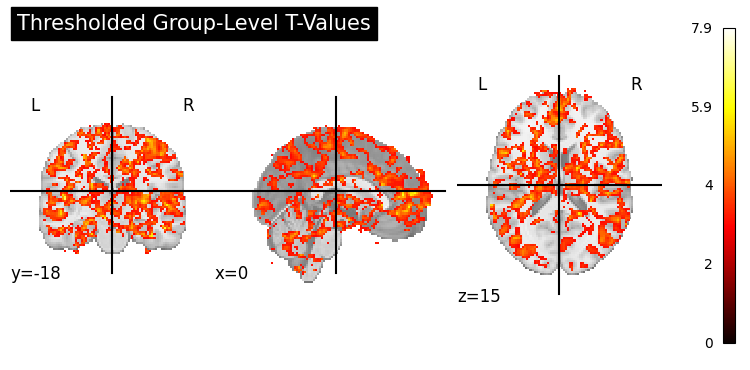

In [26]:


# Load the t-values and p-values images
# t_img_file = 'path_to_output_directory/group_t_values.nii'  # Replace with your file path
# p_img_file = 'path_to_output_directory/group_p_values.nii'  # Replace with your file path

# t_img = nib.load(t_img_file)
# p_img = nib.load(p_img_file)

t_data = t_img.get_fdata()
p_data = p_img.get_fdata()

# Define a threshold for p-values (e.g., 0.05)
p_threshold = 0.01

# Create a mask for significant p-values
significant_mask = p_data < p_threshold

# Apply the mask to the t-values
significant_t_data = np.where(significant_mask, t_data, 0)

# Create a new NIfTI image for the thresholded t-values
significant_t_img = nib.Nifti1Image(significant_t_data, t_img.affine)

# Save the thresholded t-values image (optional)
thresholded_t_img_file = './glm1/thresholded_group_t_values.nii'
nib.save(significant_t_img, thresholded_t_img_file)

# Plot the thresholded t-values image using nilearn
plot_stat_map(significant_t_img, threshold=0.0, cmap="hot", title='Thresholded Group-Level T-Values')
# plot_glass_brain(significant_t_img, title='Thresholded Group-Level T-Values (Glass Brain)')

plt.show()


In [27]:
np.sum(significant_mask)

87855

## Import SPM second-level results

In [28]:
significant_t_img = nib.load('/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/bids_fmri_data/group_level_analysis/backgroundEff/no_cluster_spm_img_fixed.nii') 

## dmPFC

Number of voxels in the masked image: 278
Peak activation voxel (MNI coordinates): [ 2. 56. 12.], t = 6.2116498947143555


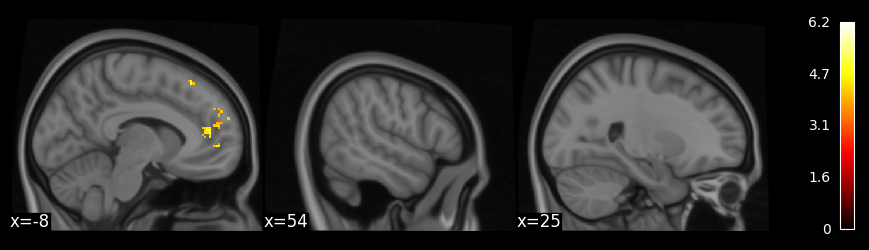

In [73]:

# Load images
mask_img = nib.load('/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/masks/neurovault/dmPFC.nii')
# mni_img = nib.load('/Users/proghani/spm-main/canonical/avg152T1.nii')
mni_img = nib.load('/Users/proghani/fsl/data/standard/MNI152_T1_0.5mm.nii.gz')


# Resample the mask to match the functional image
resampled_mask_img = resample_to_img(mask_img, significant_t_img, interpolation='nearest')

# Get the data from the images
func_data = significant_t_img.get_fdata()
mask_data = resampled_mask_img.get_fdata()

# Apply the mask
masked_data = func_data * mask_data

# Calculate the number of non-zero voxels
num_voxels = np.count_nonzero(masked_data)
print(f'Number of voxels in the masked image: {num_voxels}')

# Find the voxel with the peak activation
peak_value = np.max(masked_data)
peak_coords = np.unravel_index(np.argmax(masked_data), masked_data.shape)
peak_coords_mni = nib.affines.apply_affine(significant_t_img.affine, peak_coords)

print(f'Peak activation voxel (MNI coordinates): {peak_coords_mni}, t = {peak_value}')

# Create a new NIfTI image for the masked data
masked_img = nib.Nifti1Image(masked_data, affine=significant_t_img.affine, header=significant_t_img.header)

# Visualize the functional image overlaid on the anatomical image with the mask applied
plot_stat_map(masked_img, bg_img=mni_img, threshold=0.0, cmap='hot', display_mode='x', cut_coords=(-8, 54, 25), draw_cross=False,black_bg=True, dim=1)
# plot_stat_map(masked_img, bg_img=mni_img, threshold=1e-6, cmap='hot', display_mode='x', cut_coords=None, colorbar= True, draw_cross=False)

plt.show()

In [5]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn.image import resample_to_img
from nilearn.plotting import plot_stat_map

def find_best_cut_coords(masked_data, threshold=0.0):
    coords_range = np.argwhere(masked_data > threshold)
    
    best_coords = None
    max_voxels = 0
    
    for coord in coords_range:
        # Count activated voxels in the slices intersecting at this coordinate
        num_voxels_in_view = (
            np.count_nonzero(masked_data[coord[0], :, :] > threshold) +
            np.count_nonzero(masked_data[:, coord[1], :] > threshold) +
            np.count_nonzero(masked_data[:, :, coord[2]] > threshold)
        )
        
        if num_voxels_in_view > max_voxels:
            max_voxels = num_voxels_in_view
            best_coords = coord
    
    return best_coords, max_voxels

# Load images
mask_img = nib.load('/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/masks/neurovault/dmPFC.nii')
# Replace this line with your significant_t_img loading
# significant_t_img = nib.load('/path/to/your/significant_t_img.nii')

# Resample the mask to match the functional image
resampled_mask_img = resample_to_img(mask_img, significant_t_img, interpolation='nearest')

# Get the data from the images
func_data = significant_t_img.get_fdata()
mask_data = resampled_mask_img.get_fdata()

# Apply the mask
masked_data = func_data * mask_data

# Find the best cut coordinates
best_coords, max_voxels = find_best_cut_coords(masked_data, threshold=0.0)
print(f'Best cut coordinates (voxel indices): {best_coords}, with {max_voxels} activated voxels in view.')

# Convert voxel indices to MNI coordinates
best_coords_mni = nib.affines.apply_affine(significant_t_img.affine, best_coords)
print(f'Best cut coordinates (MNI): {best_coords_mni}')



Best cut coordinates (voxel indices): [35 80 45], with 3 activated voxels in view.
Best cut coordinates (MNI): [ 8. 48. 20.]


## vmPFC

Number of voxels in the masked image: 74
Peak activation voxel (MNI coordinates): [-6. 58. -8.], t = 5.0835041999816895


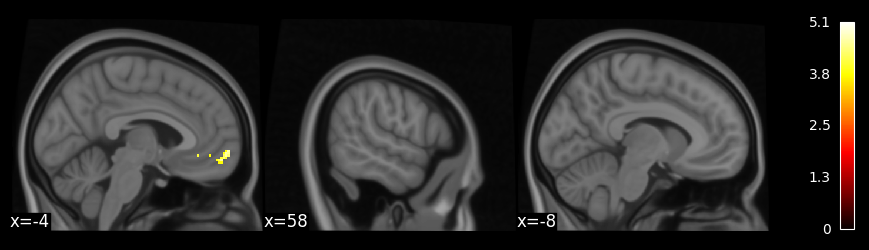

In [78]:
from nilearn.image import resample_to_img

mask_img = nib.load('/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/masks/neurovault/corrected_vmPFC_bin.nii')  # Update this path to your mask image
# mni_img = nib.load('/Users/proghani/spm-main/canonical/avg152T1.nii')
mni_img = nib.load('/Users/proghani/fsl/data/standard/MNI152_T1_0.5mm.nii.gz')

# Resample the mask to match the functional image
resampled_mask_img = resample_to_img(mask_img, significant_t_img, interpolation='nearest')

# Get the data from the images
func_data = significant_t_img.get_fdata()
mask_data = resampled_mask_img.get_fdata()

# Apply the mask
masked_data = func_data * mask_data

# Calculate the number of non-zero voxels
num_voxels = np.count_nonzero(masked_data)
print(f'Number of voxels in the masked image: {num_voxels}')

# Find the voxel with the peak activation
peak_value = np.max(masked_data)
peak_coords = np.unravel_index(np.argmax(masked_data), masked_data.shape)
peak_coords_mni = nib.affines.apply_affine(significant_t_img.affine, peak_coords)

print(f'Peak activation voxel (MNI coordinates): {peak_coords_mni}, t = {peak_value}')

# Create a new NIfTI image for the masked data
masked_img = nib.Nifti1Image(masked_data, affine=significant_t_img.affine, header=significant_t_img.header)

# Visualize the functional image overlaid on the anatomical image with the mask applied
plot_stat_map(masked_img, bg_img=mni_img, threshold=0.0, cmap='hot', display_mode='x', cut_coords=(-4, 58, -8), draw_cross=False,black_bg=True, dim=1)
# plot_stat_map(masked_img, bg_img=mni_img, threshold=1e-6, cmap='hot', display_mode='x', cut_coords=None, colorbar= True, draw_cross=False)

plt.show()

In [76]:
# Find the best cut coordinates
best_coords, max_voxels = find_best_cut_coords(masked_data, threshold=0.0)
print(f'Best cut coordinates (voxel indices): {best_coords}, with {max_voxels} activated voxels in view.')

# Convert voxel indices to MNI coordinates
best_coords_mni = nib.affines.apply_affine(significant_t_img.affine, best_coords)
print(f'Best cut coordinates (MNI): {best_coords_mni}')

Best cut coordinates (voxel indices): [41 85 31], with 42 activated voxels in view.
Best cut coordinates (MNI): [-4. 58. -8.]


### ACC

Number of voxels in the masked image: 12
Peak activation voxel (MNI coordinates): [ 2. 40. 10.], t = 5.567564009323817


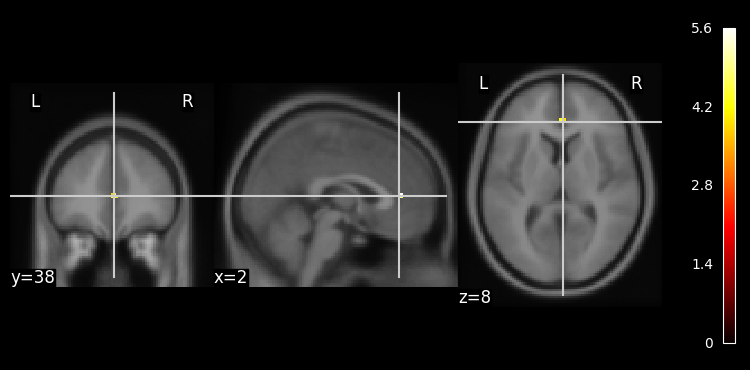

In [81]:
mask_img = nib.load('/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/masks/neurovault/corrected_DMN_and_EMO_or_SOC__ACC.nii')  # Update this path to your mask image
mni_img = nib.load('/Users/proghani/spm-main/canonical/avg152T1.nii')

# Resample the mask to match the functional image
resampled_mask_img = resample_to_img(mask_img, significant_t_img, interpolation='nearest')

# Get the data from the images
func_data = significant_t_img.get_fdata()
mask_data = resampled_mask_img.get_fdata()

# Apply the mask
masked_data = func_data * mask_data

# Calculate the number of non-zero voxels
num_voxels = np.count_nonzero(masked_data)
print(f'Number of voxels in the masked image: {num_voxels}')

# Find the voxel with the peak activation
peak_value = np.max(masked_data)
peak_coords = np.unravel_index(np.argmax(masked_data), masked_data.shape)
peak_coords_mni = nib.affines.apply_affine(significant_t_img.affine, peak_coords)

print(f'Peak activation voxel (MNI coordinates): {peak_coords_mni}, t = {peak_value}')

# Create a new NIfTI image for the masked data
masked_img = nib.Nifti1Image(masked_data, affine=significant_t_img.affine, header=significant_t_img.header)

# Visualize the functional image overlaid on the anatomical image with the mask applied
plot_stat_map(masked_img, bg_img=mni_img, threshold=0.0, cmap='hot', display_mode='ortho', cut_coords=(2, 38, 8))

plt.show()

In [80]:
# Find the best cut coordinates
best_coords, max_voxels = find_best_cut_coords(masked_data, threshold=0.0)
print(f'Best cut coordinates (voxel indices): {best_coords}, with {max_voxels} activated voxels in view.')

# Convert voxel indices to MNI coordinates
best_coords_mni = nib.affines.apply_affine(significant_t_img.affine, best_coords)
print(f'Best cut coordinates (MNI): {best_coords_mni}')

Best cut coordinates (voxel indices): [38 75 39], with 15 activated voxels in view.
Best cut coordinates (MNI): [ 2. 38.  8.]


### VTA/SN

Number of voxels in the masked image: 34
Peak activation voxel (MNI coordinates): [-12. -18.  -8.], t = 4.787515640258789


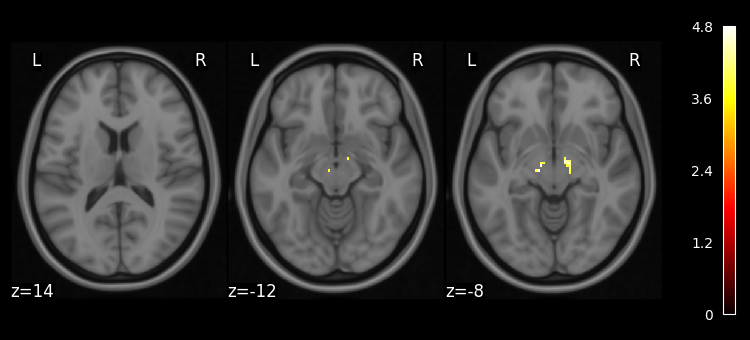

In [86]:
mask_img = nib.load('/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/masks/neurovault/corrected_MNI_res-epi_label-VTASN_mask.nii')  # Update this path to your mask image
# mni_img = nib.load('/Users/proghani/spm-main/canonical/avg152T1.nii')
mni_img = nib.load('/Users/proghani/fsl/data/standard/MNI152_T1_0.5mm.nii.gz')

# Resample the mask to match the functional image
resampled_mask_img = resample_to_img(mask_img, significant_t_img, interpolation='nearest')

# Get the data from the images
func_data = significant_t_img.get_fdata()
mask_data = resampled_mask_img.get_fdata()

# Apply the mask
masked_data = func_data * mask_data

# Calculate the number of non-zero voxels
num_voxels = np.count_nonzero(masked_data)
print(f'Number of voxels in the masked image: {num_voxels}')

# Find the voxel with the peak activation
peak_value = np.max(masked_data)
peak_coords = np.unravel_index(np.argmax(masked_data), masked_data.shape)
peak_coords_mni = nib.affines.apply_affine(significant_t_img.affine, peak_coords)

print(f'Peak activation voxel (MNI coordinates): {peak_coords_mni}, t = {peak_value}')

# Create a new NIfTI image for the masked data
masked_img = nib.Nifti1Image(masked_data, affine=significant_t_img.affine, header=significant_t_img.header)

# Visualize the functional image overlaid on the anatomical image with the mask applied
plot_stat_map(masked_img, bg_img=mni_img, threshold=0.0, cmap='hot', display_mode='z', cut_coords=(14, -12, -8), draw_cross=False,black_bg=True, dim=1)
# plot_stat_map(masked_img, bg_img=mni_img, threshold=1e-6, cmap='hot', display_mode='x', cut_coords=None, colorbar= True, draw_cross=False)

plt.show()

In [83]:
# Find the best cut coordinates
best_coords, max_voxels = find_best_cut_coords(masked_data, threshold=0.0)
print(f'Best cut coordinates (voxel indices): {best_coords}, with {max_voxels} activated voxels in view.')

# Convert voxel indices to MNI coordinates
best_coords_mni = nib.affines.apply_affine(significant_t_img.affine, best_coords)
print(f'Best cut coordinates (MNI): {best_coords_mni}')

Best cut coordinates (voxel indices): [32 50 31], with 34 activated voxels in view.
Best cut coordinates (MNI): [ 14. -12.  -8.]


## glm2

In [70]:
# Set the parent directory where the contrast images are stored
parent_dir = '/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/bids_fmri_data/'  # Replace with your parent directory

# Recursively find all contrast images named 'ess_0001.nii'
contrast_files = sorted(glob.glob(os.path.join(parent_dir, '**', 'glm2/ess_0001.nii'), recursive=True))

# Check if we have any files
if not contrast_files:
    raise FileNotFoundError("No contrast images found in the specified directory.")

In [71]:
# Load the contrast images and stack them into a 4D array
contrast_imgs = [nib.load(img_file) for img_file in contrast_files]
contrast_data = np.stack([img.get_fdata() for img in contrast_imgs], axis=-1)

In [72]:
len(contrast_imgs)

9

In [73]:
# setting nan values to zero
contrast_data = np.nan_to_num(contrast_data, nan=0.0)

In [74]:
# # Perform group-level analysis (one-sample t-test against zero)
t_vals, p_vals = safe_ttest_1samp(contrast_data, 0)

# Create NIfTI images for the t-values and p-values
affine = contrast_imgs[0].affine
t_img = nib.Nifti1Image(t_vals, affine)
p_img = nib.Nifti1Image(p_vals, affine)

# Save the resulting images
output_dir = './'  # Replace with your output directory
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

t_img_file = os.path.join(output_dir, 'glm2/group_t_values.nii')
p_img_file = os.path.join(output_dir, 'glm2/group_p_values.nii')

nib.save(t_img, t_img_file)
nib.save(p_img, p_img_file)

print(f"Group-level t-values saved to {t_img_file}")
print(f"Group-level p-values saved to {p_img_file}")

Group-level t-values saved to ./glm2/group_t_values.nii
Group-level p-values saved to ./glm2/group_p_values.nii


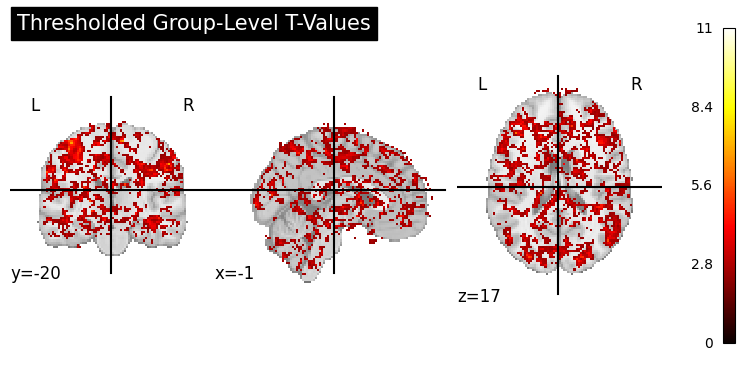

In [75]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn.plotting import plot_stat_map, plot_glass_brain

# Load the t-values and p-values images
# t_img_file = 'path_to_output_directory/group_t_values.nii'  # Replace with your file path
# p_img_file = 'path_to_output_directory/group_p_values.nii'  # Replace with your file path

# t_img = nib.load(t_img_file)
# p_img = nib.load(p_img_file)

t_data = t_img.get_fdata()
p_data = p_img.get_fdata()

# Define a threshold for p-values (e.g., 0.05)
p_threshold = 0.05

# Create a mask for significant p-values
significant_mask = p_data < p_threshold

# Apply the mask to the t-values
significant_t_data = np.where(significant_mask, t_data, 0)

# Create a new NIfTI image for the thresholded t-values
significant_t_img = nib.Nifti1Image(significant_t_data, t_img.affine)

# Save the thresholded t-values image (optional)
thresholded_t_img_file = './glm2/thresholded_group_t_values.nii'
nib.save(significant_t_img, thresholded_t_img_file)

# Plot the thresholded t-values image using nilearn
plot_stat_map(significant_t_img, threshold=0.0, cmap="hot", title='Thresholded Group-Level T-Values')
# plot_glass_brain(significant_t_img, title='Thresholded Group-Level T-Values (Glass Brain)')

plt.show()


## Import SPM second-level results

In [6]:
significant_t_img = nib.load('/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/bids_fmri_data/group_level_analysis/predictionErr/no_cluster_spm_img_fixed.nii') 

## dmPFC

Number of voxels in the masked image: 1
Peak activation voxel (MNI coordinates): [ 8. 48. 20.], t = 3.771110773086548


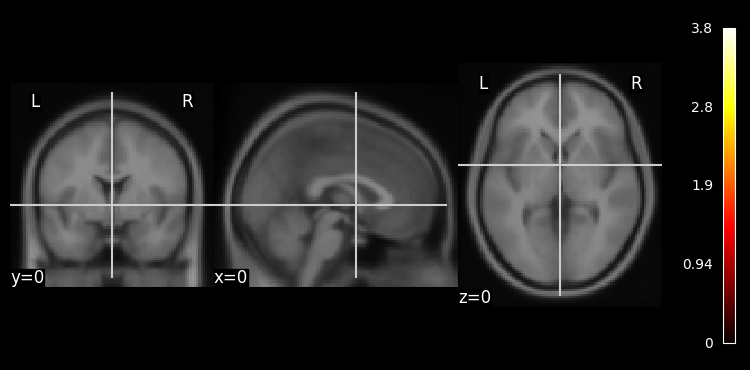

In [75]:
from nilearn.image import resample_to_img

mask_img = nib.load('/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/masks/neurovault/dmPFC.nii')  # Update this path to your mask image
mni_img = nib.load('/Users/proghani/spm-main/canonical/avg152T1.nii')

# Resample the mask to match the functional image
resampled_mask_img = resample_to_img(mask_img, significant_t_img, interpolation='nearest')

# Get the data from the images
func_data = significant_t_img.get_fdata()
mask_data = resampled_mask_img.get_fdata()

# Apply the mask
masked_data = func_data * mask_data

# Calculate the number of non-zero voxels
num_voxels = np.count_nonzero(masked_data)
print(f'Number of voxels in the masked image: {num_voxels}')

# Find the voxel with the peak activation
peak_value = np.max(masked_data)
peak_coords = np.unravel_index(np.argmax(masked_data), masked_data.shape)
peak_coords_mni = nib.affines.apply_affine(significant_t_img.affine, peak_coords)

print(f'Peak activation voxel (MNI coordinates): {peak_coords_mni}, t = {peak_value}')

# Create a new NIfTI image for the masked data
masked_img = nib.Nifti1Image(masked_data, affine=significant_t_img.affine, header=significant_t_img.header)

# Visualize the functional image overlaid on the anatomical image with the mask applied
plot_stat_map(masked_img, bg_img=mni_img, threshold=0.0, cmap='hot', display_mode='ortho', cut_coords=(0, 0, 0))

plt.show()


## vmPFC

Number of voxels in the masked image: 14
Peak activation voxel (MNI coordinates): [-4. 46. -8.], t = 4.741988658905029


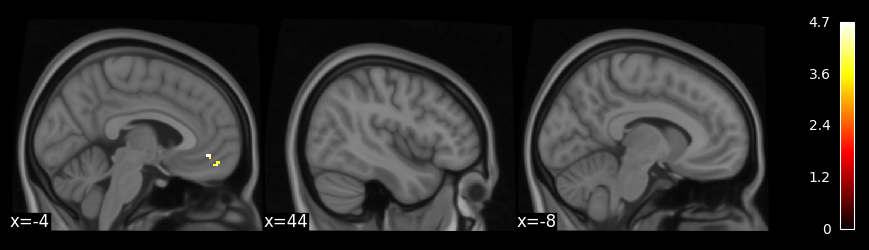

In [10]:
from nilearn.image import resample_to_img

mask_img = nib.load('/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/masks/neurovault/corrected_vmPFC_bin.nii')  # Update this path to your mask image
# mni_img = nib.load('/Users/proghani/spm-main/canonical/avg152T1.nii')
mni_img = nib.load('/Users/proghani/fsl/data/standard/MNI152_T1_0.5mm.nii.gz')

# Resample the mask to match the functional image
resampled_mask_img = resample_to_img(mask_img, significant_t_img, interpolation='nearest')

# Get the data from the images
func_data = significant_t_img.get_fdata()
mask_data = resampled_mask_img.get_fdata()

# Apply the mask
masked_data = func_data * mask_data

# Calculate the number of non-zero voxels
num_voxels = np.count_nonzero(masked_data)
print(f'Number of voxels in the masked image: {num_voxels}')

# Find the voxel with the peak activation
peak_value = np.max(masked_data)
peak_coords = np.unravel_index(np.argmax(masked_data), masked_data.shape)
peak_coords_mni = nib.affines.apply_affine(significant_t_img.affine, peak_coords)

print(f'Peak activation voxel (MNI coordinates): {peak_coords_mni}, t = {peak_value}')

# Create a new NIfTI image for the masked data
masked_img = nib.Nifti1Image(masked_data, affine=significant_t_img.affine, header=significant_t_img.header)

# Visualize the functional image overlaid on the anatomical image with the mask applied
plot_stat_map(masked_img, bg_img=mni_img, threshold=0.0, cmap='hot', display_mode='x', cut_coords=(-4, 44, -8), draw_cross=False,black_bg=True, dim=1)
# plot_stat_map(masked_img, bg_img=mni_img, threshold=1e-6, cmap='hot', display_mode='x', cut_coords=None, colorbar= True, draw_cross=False)

plt.show()

In [8]:
# Find the best cut coordinates
best_coords, max_voxels = find_best_cut_coords(masked_data, threshold=0.0)
print(f'Best cut coordinates (voxel indices): {best_coords}, with {max_voxels} activated voxels in view.')

# Convert voxel indices to MNI coordinates
best_coords_mni = nib.affines.apply_affine(significant_t_img.affine, best_coords)
print(f'Best cut coordinates (MNI): {best_coords_mni}')

Best cut coordinates (voxel indices): [41 78 31], with 16 activated voxels in view.
Best cut coordinates (MNI): [-4. 44. -8.]


### ACC

Number of voxels in the masked image: 2
Peak activation voxel (MNI coordinates): [ 2. 38.  8.], t = 4.081554411891486


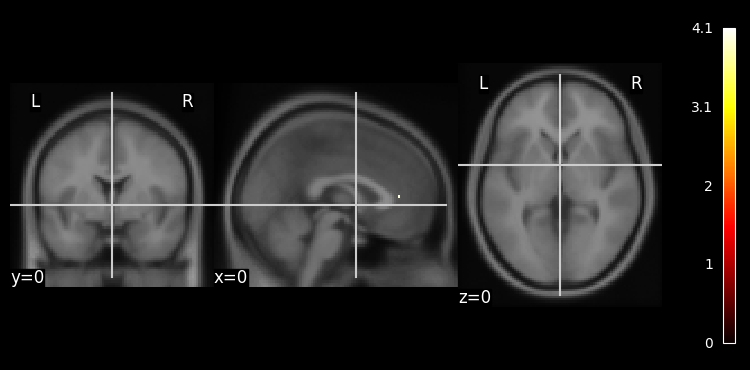

In [77]:
mask_img = nib.load('/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/masks/neurovault/corrected_DMN_and_EMO_or_SOC__ACC.nii')  # Update this path to your mask image
mni_img = nib.load('/Users/proghani/spm-main/canonical/avg152T1.nii')

# Resample the mask to match the functional image
resampled_mask_img = resample_to_img(mask_img, significant_t_img, interpolation='nearest')

# Get the data from the images
func_data = significant_t_img.get_fdata()
mask_data = resampled_mask_img.get_fdata()

# Apply the mask
masked_data = func_data * mask_data

# Calculate the number of non-zero voxels
num_voxels = np.count_nonzero(masked_data)
print(f'Number of voxels in the masked image: {num_voxels}')

# Find the voxel with the peak activation
peak_value = np.max(masked_data)
peak_coords = np.unravel_index(np.argmax(masked_data), masked_data.shape)
peak_coords_mni = nib.affines.apply_affine(significant_t_img.affine, peak_coords)

print(f'Peak activation voxel (MNI coordinates): {peak_coords_mni}, t = {peak_value}')

# Create a new NIfTI image for the masked data
masked_img = nib.Nifti1Image(masked_data, affine=significant_t_img.affine, header=significant_t_img.header)

# Visualize the functional image overlaid on the anatomical image with the mask applied
plot_stat_map(masked_img, bg_img=mni_img, threshold=0.0, cmap='hot', display_mode='ortho', cut_coords=(0, 0, 0))

plt.show()

### VTA/SN

Number of voxels in the masked image: 28
Peak activation voxel (MNI coordinates): [-10. -16. -14.], t = 4.87202787399292


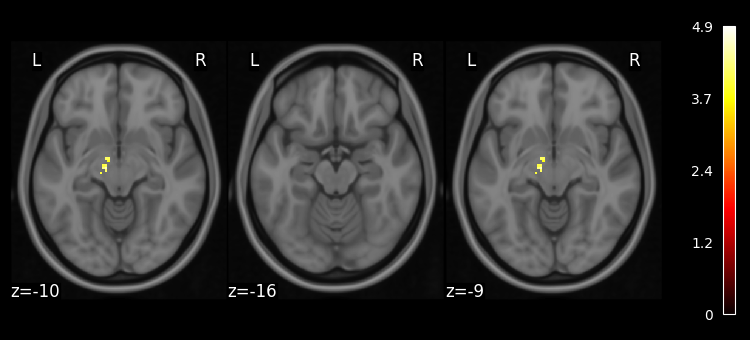

In [98]:
mask_img = nib.load('/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/masks/neurovault/corrected_MNI_res-epi_label-VTASN_mask.nii')  # Update this path to your mask image
# mni_img = nib.load('/Users/proghani/spm-main/canonical/avg152T1.nii')
mni_img = nib.load('/Users/proghani/fsl/data/standard/MNI152_T1_0.5mm.nii.gz')

# Resample the mask to match the functional image
resampled_mask_img = resample_to_img(mask_img, significant_t_img, interpolation='nearest')

# Get the data from the images
func_data = significant_t_img.get_fdata()
mask_data = resampled_mask_img.get_fdata()

# Apply the mask
masked_data = func_data * mask_data

# Calculate the number of non-zero voxels
num_voxels = np.count_nonzero(masked_data)
print(f'Number of voxels in the masked image: {num_voxels}')

# Find the voxel with the peak activation
peak_value = np.max(masked_data)
peak_coords = np.unravel_index(np.argmax(masked_data), masked_data.shape)
peak_coords_mni = nib.affines.apply_affine(significant_t_img.affine, peak_coords)

print(f'Peak activation voxel (MNI coordinates): {peak_coords_mni}, t = {peak_value}')

# Create a new NIfTI image for the masked data
masked_img = nib.Nifti1Image(masked_data, affine=significant_t_img.affine, header=significant_t_img.header)

# Visualize the functional image overlaid on the anatomical image with the mask applied
plot_stat_map(masked_img, bg_img=mni_img, threshold=0.0, cmap='hot', display_mode='z', cut_coords=(-10, -16, -9), draw_cross=False,black_bg=True, dim=1)
# plot_stat_map(masked_img, bg_img=mni_img, threshold=1e-6, cmap='hot', display_mode='x', cut_coords=None, colorbar= True, draw_cross=False)

plt.show()

In [89]:
# Find the best cut coordinates
best_coords, max_voxels = find_best_cut_coords(masked_data, threshold=0.0)
print(f'Best cut coordinates (voxel indices): {best_coords}, with {max_voxels} activated voxels in view.')

# Convert voxel indices to MNI coordinates
best_coords_mni = nib.affines.apply_affine(significant_t_img.affine, best_coords)
print(f'Best cut coordinates (MNI): {best_coords_mni}')

Best cut coordinates (voxel indices): [44 48 30], with 25 activated voxels in view.
Best cut coordinates (MNI): [-10. -16. -10.]
